# Mini-project I: Parameter estimation for a toy model of an EFT

The overall project goal is to reproduce various results in this paper: [*Bayesian parameter estimation for effective field theories*](https://arxiv.org/abs/1511.03618).  It's a long paper, so don't try to read all of it!  (At least not now.)  We'll guide you to the relevant parts.

The paper uses toy models for effective field theories, namely Taylor series of some specified functions, to present guidelines for parameter estimation. This will also be a check of whether you can follow (or give you practice on) Bayesian statistics discussions in the physics literature.

You'll find summaries in section II that touch on topics we have discussed and will discuss.  The function 

$$
g(x) = \left(\frac12 + \tan\left(\frac{\pi}{2}x\right)\right)^2
$$

represents the true, underlying theory.  It has a Taylor expansion

$$
g(x) = 0.25 + 1.57x + 2.47x^2 + 1.29 x^3 + \cdots
$$

Our model for an EFT for this "theory" is

$$
g_{\rm th}(x) \equiv \sum_{i=0}^k a_i x^i
$$

and your general task is to fit 1, 2, 3, ... of the constants $a_i$, and analyze the results.
**Your primary goal is to reproduce and interpret Table III on page 12 of the arXiv preprint.  A secondary goal is to reproduce and interpret Figure 1 of the same paper.**  You should use the emcee sampler and corner to make plots.


<div style="float:center;"><img src="https://raw.githubusercontent.com/buqeye/LearningFromData/main/LectureNotes/_images/miniproject_I_figure.png" width=700px></div>


## Learning goals:
* Apply and extend the Bayesian parameter estimation ideas and techniques from the course.
* Explore the impact of control features:  dependence on how much data is used and how precise it is; apply an *informative* prior.
* Learn about some diagnostics for Bayesian parameter estimation.
* Try out sampling on a controlled problem.

## Suggestions for how to proceed:
* Follow the lead of the notebooks [Gaussian noise](https://buqeye.github.io/LearningFromData/notebooks/MCMC_sampling_I/parameter_estimation_Gaussian_noise-2.html) and [Fitting a straight line II [ipynb]](https://buqeye.github.io/LearningFromData/notebooks/Why_Bayes_is_better/parameter_estimation_fitting_straight_line_II.html).
* Define a function for the exact result plus noise, noting from the arXiv paper what type of noise is added and where the points are located (i.e., what values of $x$). 
* Define functions for the two choices of prior and for the likelihood. Also a function for the posterior.
* Call emcee to sample the posteriors.
* Use corner to create plots.  You can read the answers for the tables from the corner plots (it is also possible to extract the numbers directly: see the example at the bottom of [this page](https://emcee.readthedocs.io/en/latest/tutorials/line/) from the emcee documentation).
* Don't try to do too much in your code at first (start with the lowest order in Table III). 
* Fill in the rest of Table III.  Characterize and explain the different results from the two priors (also: which one is equivalent to standard least-squares fitting?).  
* Generate figures for the lowest orders analogous to Figure 1 and then reproduce Figure 1.  Interpret the projected posteriors (e.g., what coefficients are very correlated and how does this relate to overfitting?) and identify where the "prior is returned". 


## Comments and suggestions
* To reproduce precisely (within fluctuations from the sampling) the numbers in Table III, you'll need to use the same data set used in the table.  This is available from the arXiv as [D1_c_5.dat](https://arxiv.org/src/1511.03618v3/anc/D1_c_5.dat).  These values are those plotted in the figure at the top of this notebook.
* The 5% error is a *relative* error, meaning it is 0.05 times the data at that point.  This means if you generate a Gaussian random number `err` distributed with standard deviation 0.05, the value of sigma for the log likelihood is `sigma[i] = data[i] * err` (use the data, not the theory at `i`).
* The `show_titles=True` option to corner will show central results and one-$\sigma$ error limits on the projected posterior plots.
* The `quantiles=[0.16, 0.5, 0.84]`option to corner adds the dashed vertical lines to the marginal posteriors on the diagonal. You can obviously change the quantiles if you want another credibility region.
* The Python command `np.percentile(samples, [16, 50, 84],axis=0)` might be useful to extract numerical values for the credibility region and the mean from a python array `samples`of shape (nsamples,ndimensions).
* The example on [Fitting a Model to Data](https://emcee.readthedocs.io/en/v2.2.1/user/line/) from the emcee documentation may be useful to supplement the examples in the other notebooks.
* Defining Python functions to do the sampling and plotting will make it much more efficient (and easier) to generate the numbers in the table or the particular plots for figure 1.

## Bonus: additional subtasks 

Do one or more of these to get a plus.

* Reproduce Figures 3 and 4, showing the predictions with error bands for the two priors compared to the true function.  You can use Matplotlib's `fill_between(x, y-error, y+error)` to make bands.  (Use the `alpha` keyword for `fill_between`, e.g., `alpha=0.5`, to make the bands more transparent.)
* Reproduce Figure 5 (alternative prior and "returning the prior"), 
* Reproduce Figure 6 (posterior for $\overline a$), and 7 ("relaxing to least squares").  
* Reproduce Figure 9 (sensitivity to choice of $x_{\rm max}$)
* Repeat analysis with same function but different data precision and/or quantity (number of data points).
* Repeat analysis with a different function from the paper or invent your own function and analyze.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas
from scipy import stats
import emcee
import corner

In [2]:
# Let's read the data using pandas.
url = "https://arxiv.org/src/1511.03618v3/anc/D1_c_5.dat"
names = ['x_data', 'y_data', 'dy_data']
# Note that the data file uses one or more tabs as separators. So the regex '\t+' is needed
# and this calls for engine='python'
# Comment lines starting with '#' should be ignored
data = pandas.read_csv(url, names=names, sep='\t+', engine='python', comment='#')
print(f'Read data from {url} into a pandas data frame with shape: {data.shape}')
print('This data must be used to reproduce the results in Table III')
display(data)

# Copy the data into numpy arrays

x_data_pts = data['x_data'].to_numpy()
y_data_pts = data['y_data'].to_numpy()
dy_data = data['dy_data'].to_numpy()


Read data from https://arxiv.org/src/1511.03618v3/anc/D1_c_5.dat into a pandas data frame with shape: (10, 3)
This data must be used to reproduce the results in Table III


,x_data,y_data,dy_data
0,0.03183,0.31694,0.015850
1,0.06366,0.33844,0.016920
2,0.09549,0.42142,0.021070
3,0.12732,0.57709,0.028850
4,0.15915,0.56218,0.028110
5,0.19099,0.68851,0.034430
6,0.22282,0.73625,0.036810
7,0.25465,0.87270,0.043640
8,0.28648,1.00150,0.050075
9,0.31831,1.06840,0.053420


In [3]:
def g_fun(x):
    """
    Toy function to model an EFT expansion.  It has a Taylor expansion about
    x=0 with a radius of convergence of 1.
    """
    return (0.5 + np.tan(np.pi * x / 2.))**2

def y_model(x_pts, theta, orders=None):
    """
    Returns the evaluation of the theoretical model at all x values in the
    numpy array x_pts, using coefficients from theta, where orders is the
    number of coefficients to use (if orders is not specified in the call
    to y_model, it is assigned None and this means to use all the coefficients 
    in theta).
    
    The theoretical model is (with n = orders - 1):
      y_model(x) = theta_0 + theta_1 * x + ... + theta_n * x**n
                 = \sum_{i=0}^{orders} theta_i x^i
                 
    This is cleanly implemented using a nested list comprehension.             
    """
    
    if orders is None:   # use the full theta vector
        orders = len(theta)
    
    return np.array( [ np.sum(
                               [theta[i] * x**i for i in range(orders)]
                             ) for x in x_pts ] )

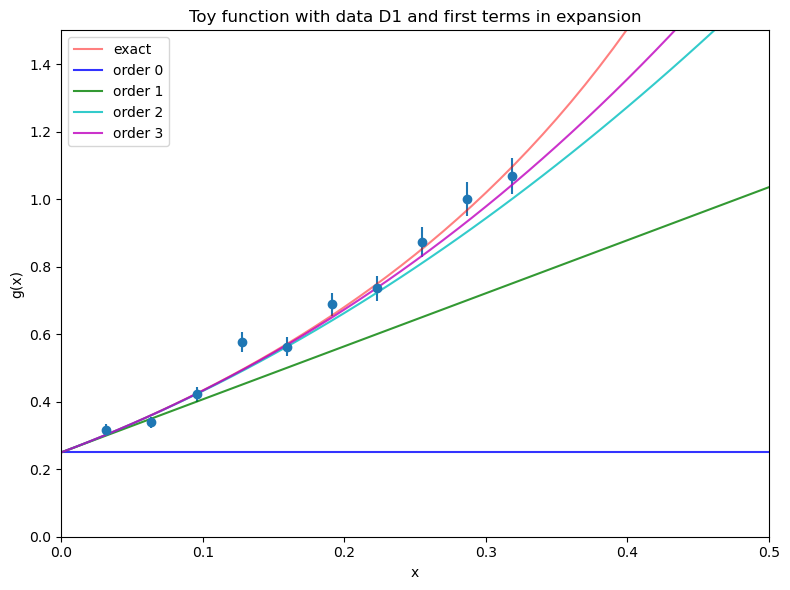

In [4]:
# Always make a figure to check!

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.errorbar(x_data_pts, y_data_pts, dy_data, fmt='o')
ax.set_xlabel(r'x')
ax.set_ylabel(r'g(x)')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1.5)

x_pts_all = np.arange(0., 1., .01)
ax.plot(x_pts_all, g_fun(x_pts_all), color='red', alpha=0.5, label='exact')
ax.set_title('Toy function with data D1 and first terms in expansion')

theta_true = np.array([0.25, 1.5707963, 2.4674011, 1.2919282, 4.0587121,
                       1.275082, 5.67486677])
colors = ['b', 'g', 'c', 'm', 'k', 'r', 'b']

n_dim = 4
for order in range(n_dim):
    ax.plot(x_pts_all, y_model(x_pts_all, theta_true[:n_dim], order+1), 
            label=f'order {order:d}', color=colors[order], alpha=0.8)

ax.legend()


fig.tight_layout()

In [5]:
#Generate synthetic data: from 0 to x_max, evently spaced, N_d number of points
np.random.seed(None)
 
M = 100 # number of measurements
D = stats.norm.rvs(0, 1, size=None)  # M measurements (samples)

def sim_point(g, x, c):
    point = g(x) * (1 + c*stats.norm.rvs(0, 1, size=len(x)))
    return [x, point, point * c]


#actually generate the data
c = 0.05
x_pts = np.arange(0.03, 0.33, 0.03)

sim_x_pts, sim_y_pts, sim_sigma = sim_point(g_fun, x_pts, c)

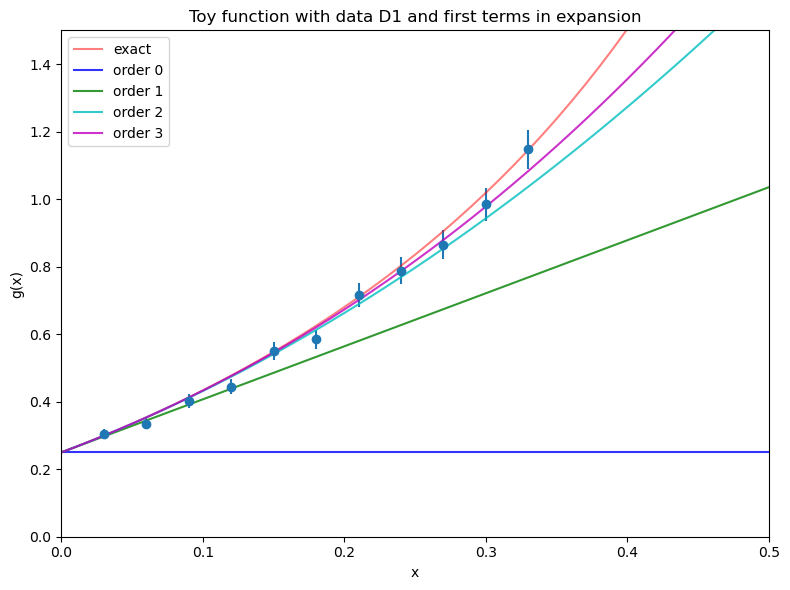

In [6]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
ax.errorbar(sim_x_pts, sim_y_pts, sim_sigma, fmt='o')
ax.set_xlabel(r'x')
ax.set_ylabel(r'g(x)')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1.5)

x_pts_all = np.arange(0., 1., .01)
ax.plot(x_pts_all, g_fun(x_pts_all), color='red', alpha=0.5, label='exact')
ax.set_title('Toy function with data D1 and first terms in expansion')

theta_true = np.array([0.25, 1.5707963, 2.4674011, 1.2919282, 4.0587121,
                       1.275082, 5.67486677])
colors = ['b', 'g', 'c', 'm', 'k', 'r', 'b']

n_dim = 4
for order in range(n_dim):
    ax.plot(x_pts_all, y_model(x_pts_all, theta_true[:n_dim], order+1), 
            label=f'order {order:d}', color=colors[order], alpha=0.8)

ax.legend()


fig.tight_layout()

The likelihood is defined by $p(a|x, y, σ) = \prod_{i=0}^{k_{max}} P(a_i|x_i, y_i, σ_i)$
<br><br>
Since we are assuming the error is gaussian, we can write this as <br>
$lnp(D∣a,σ^2)=−\frac{N}{2}ln(2πσ^{2})−\frac{1}{2σ^2}\sum_{i=1}^{N}(D_i​−a_i)^2$
<br>
where $σ^2$ is $(a_i * 0.05)^2$, which is $(a_i*c)^2$ in the code, and N is the number of orders we are going to.



In [56]:
#Define functions for the two choices of prior and for the likelihood. Also a function for the posterior.
def log_prior_flat(a):
    '''Flat log prior for parameter array a'''
    #if orders is None:   # use the full theta vector
    #    orders = len(theta)
    ## flat prior
    #for i in
    #if np.logical_and(min_theta<=theta, theta<=max_theta).all(): 
    #    return np.log(1/volume_theta)
    #else:
    #    return -np.inf
    return 0

_a_ = 5
def log_prior_gaussian(a):
    '''Gaussian log prior for parameter array a'''
    
    return np.sum(np.log(1/(np.sqrt(2*np.pi) * _a_) * np.exp(-a**2/(2*_a_**2))))
    

def log_likelihood(a, x, y, dy):
    '''Log likelihood for data a_data given x y dy parameters '''
    
    y_a = y_model(x, a)
    orders = len(a)
    
    try: 
        return -1/2 * np.sum(np.log(2*np.pi*dy**2) + (y_a - y)**2 / dy**2)
    except ValueError:
        return -np.inf

def log_posterior_flat_prior(a, x, y, dy):
    '''Log posterior for data X given parameter array theta'''
    return log_prior_flat(a) + log_likelihood(a, x, y, dy)

def log_posterior_gaussian_prior(a, x, y, dy):
    '''Log posterior for data X given parameter array theta'''
    return log_prior_gaussian(a) + log_likelihood(a, x, y, dy)

def chi_squared_over_dof(a, x, y, dy):
    '''chi squared over degrees of freedom for a given parameter array and x, y, dy data'''
    return np.sum(np.square((y_model(x, a) - y)/dy)) / len(a)

In [100]:
print('emcee sampling (version: )', emcee.__version__)

orders_to_try = 4


ndim = orders_to_try  # number of parameters in the model
nwalkers = 50  # number of MCMC walkers
nsteps = 2000 # steps per walker

print(f'{nwalkers} walkers: {nsteps} samples each')

# initialize walkers
starting_guesses = np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_gaussian_prior, args=[x_data_pts, y_data_pts, dy_data])
%time sampler.run_mcmc(starting_guesses, nsteps)

sampler_flat = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_flat_prior, args=[x_data_pts, y_data_pts, dy_data])
%time sampler_flat.run_mcmc(starting_guesses, nsteps)
print("done")

emcee sampling (version: ) 3.1.6
50 walkers: 2000 samples each
CPU times: total: 20.8 s
Wall time: 21.8 s
CPU times: total: 18.7 s
Wall time: 19.4 s
done


In [101]:
# We choose a warm-up time
nwarmup = 200 # warm up

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# we'll throw-out the warmup points and reshape:
emcee_trace = sampler.chain[:, nwarmup:, :].reshape(-1, ndim).T
emcee_lnprob = sampler.lnprobability[:, nwarmup:].reshape(-1).T

emcee_trace_flat = sampler_flat.chain[:, nwarmup:, :].reshape(-1, ndim).T
emcee_lnprob_flat = sampler_flat.lnprobability[:, nwarmup:].reshape(-1).T

In [102]:
def compute_sigma_level(trace1, trace2, nbins=20):
    """From a set of traces, bin by number of standard deviations"""
    L, xbins, ybins = np.histogram2d(trace1, trace2, nbins)
    L[L == 0] = 1E-16
    logL = np.log(L)

    shape = L.shape
    L = L.ravel()

    # obtain the indices to sort and unsort the flattened array
    i_sort = np.argsort(L)[::-1]
    i_unsort = np.argsort(i_sort)

    L_cumsum = L[i_sort].cumsum()
    L_cumsum /= L_cumsum[-1]
    
    xbins = 0.5 * (xbins[1:] + xbins[:-1])
    ybins = 0.5 * (ybins[1:] + ybins[:-1])

    return xbins, ybins, L_cumsum[i_unsort].reshape(shape)

def plot_MCMC_trace(ax, xdata, ydata, trace, scatter=False, **kwargs):
    """Plot traces and contours"""
    xbins, ybins, sigma = compute_sigma_level(trace[0], trace[1])
    ax.contour(xbins, ybins, sigma.T, levels=[0.683, 0.955, 0.997], **kwargs)
    if scatter:
        ax.plot(trace[0], trace[1], ',k', alpha=0.1)
    ax.set_xlabel(r'$\theta_0$')
    ax.set_ylabel(r'$\theta_1$')
    
# Convenience function to extract the peak position of the mode
def max_of_mode(sampler_object):
    max_arg = np.argmax(sampler.flatlnprobability)
    return(sampler.flatchain[max_arg])

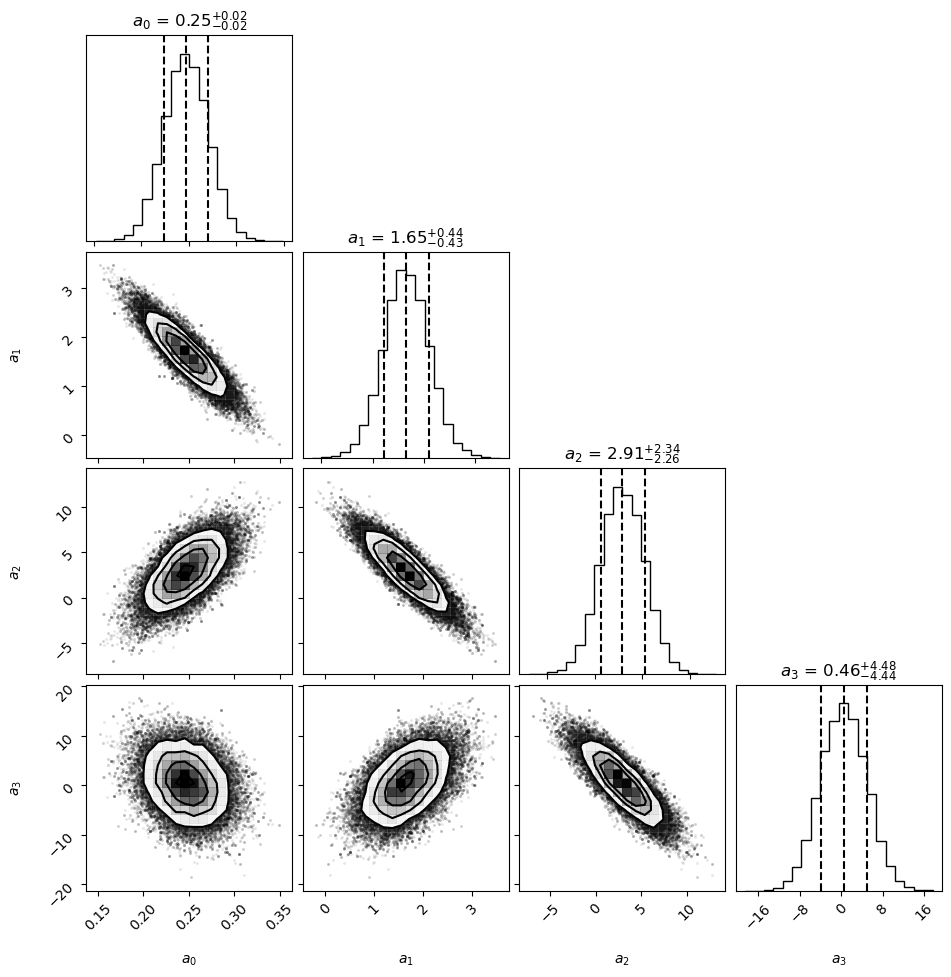

In [106]:
# Alternatively we can use corner: Gaussian prior
fig, ax = plt.subplots(orders_to_try,orders_to_try, figsize=(10,10))
a_titles = np.char.add(np.char.add(np.full(orders_to_try, "$a_"), np.arange(0, orders_to_try, 1).astype(str)), np.full(orders_to_try, "$"))
corner.corner(emcee_trace.T,labels=a_titles,
                       quantiles=[0.16, 0.5, 0.84],fig=fig,show_titles=True
                       );

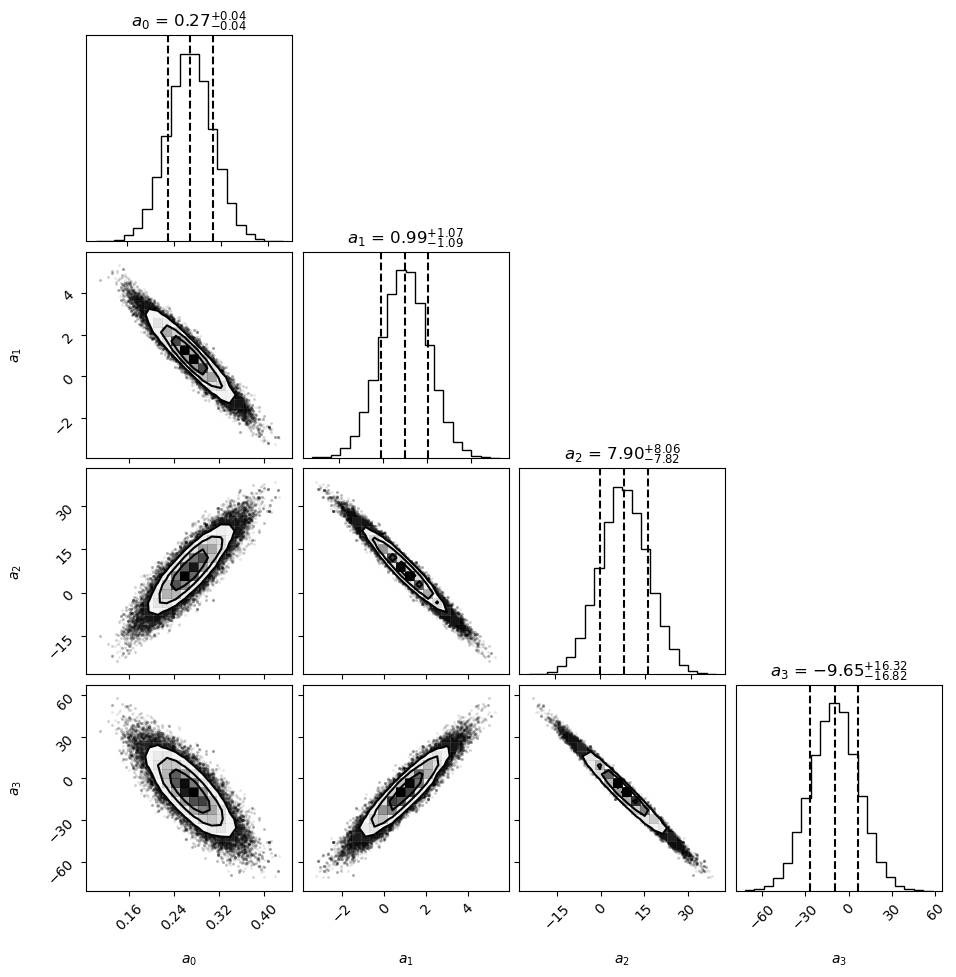

In [107]:
# Alternatively we can use corner: flat prior
fig, ax = plt.subplots(orders_to_try,orders_to_try, figsize=(10,10))
a_titles = np.char.add(np.char.add(np.full(orders_to_try, "$a_"), np.arange(0, orders_to_try, 1).astype(str)), np.full(orders_to_try, "$"))
corner.corner(emcee_trace_flat.T,labels=a_titles,
                       quantiles=[0.16, 0.5, 0.84],fig=fig,show_titles=True
                       );

In [99]:
print("chi_squared_over_dof: " + str(chi_squared_over_dof(max_of_mode(sampler_flat), x_data_pts, y_data_pts, dy_data)))

chi_squared_over_dof: 599.0087437196705


| k | k_max | chi2/dof | Uniform prior                       |                  |                  | Gaussian prior      |                |                |                |
|---|--------|----------|--------------------------------------|------------------|------------------|----------------------|----------------|----------------|----------------|
|   |        |          | a0                                   | a1               | a2               | Evidence             | a0             | a1             | a2             |
| 0 | 0      | 600       | 0.48 +/- 0.01                        |                  |                  |            | 0.48 +/- 0.01  |                |                |
| 1 | 1      | 8.9      | 0.20 +/- 0.01                        | 2.6 +/- 0.1      |                  |            | 0.20 +/- 0.01  | 2.6 +/- 0.1    |                |
| 2 | 2      | 3.8      | 0.25 +/- 0.02                        | 1.6 +/- 0.4      | 3 +/- 1      |            | 0.25 +/- 0.02  | 1.6 +/- 0.4    | 3 +/- 1      |
| 2 | 3      | 2.9      | 0.27 +/- 0.04                        | 1.0 +/- 1        | 8 +/- 8      |            | 0.25 +/- 0.02  | 1.7 +/- 0.5    | 3 +/- 2    |
| 2 | 4      | 2.3      | 0.33 +/- 0.07                        | -2 +/- 3       | 40 +/- 30        |            | 0.25 +/- 0.02  | 1.7 +/- 0.5    | 3 +/- 2    |
| 2 | 5      | 1.9      | 0.56 +/- 0.1                         | -15 +/- 7        | 270 +/- 100      |            | 0.25 +/- 0.02  | 1.6 +/- 0.5    | 3 +/- 2    |
| 2 | 6      | 1.7      | 0.57 +/- 0.3                         | -15 +/- 20       | 280 +/- 400      |            | 0.25 +/- 0.02  | 1.7 +/- 0.5    | 3 +/- 2    |
|   |        |          | **True values**                     | **0.25**         | **1.57**         |                      | **0.25**       | **1.57**       | **2.47**       |

The 2 priors return very different results. The biggest difference is in the a1 and higher coeffecients. The gaussian prior settles to something close to the correct answer, and the uniform prior doesn't really settle and is wrong for the most part. It also has much larger uncertainty. The naturalness scale here does a really good job of not letting the fitting pick crazy numbers, and so they settle to something close to the correct answer. With the other uniform prior any number can be correct as far as it knows and so if there is a fit with lots of high coefficients that is better that one will be picked. The uniform prior is equivalen to least squares fitting, and it does pretty badly here.

Figure 1 is reproduced above and then analogously with higher orders below. <br>For the gaussian prior: The factors that seem to be related are the low factors with each other. Once we get to $a_4$ we get to the point where the prior is returned. The likelihood is too wide, and so really now we can glean nothing from the data about these factors. <br> For the uniform prior: All factors are very correlated to each other. This is an indication of overfitting. If one factor slightly changes, all other factors have to change in order for the data to fit well, which is not a sign of a good fit. 

emcee sampling (version: ) 3.1.6
50 walkers: 2000 samples each
CPU times: total: 22.5 s
Wall time: 23.3 s
CPU times: total: 19.9 s
Wall time: 20.6 s
done


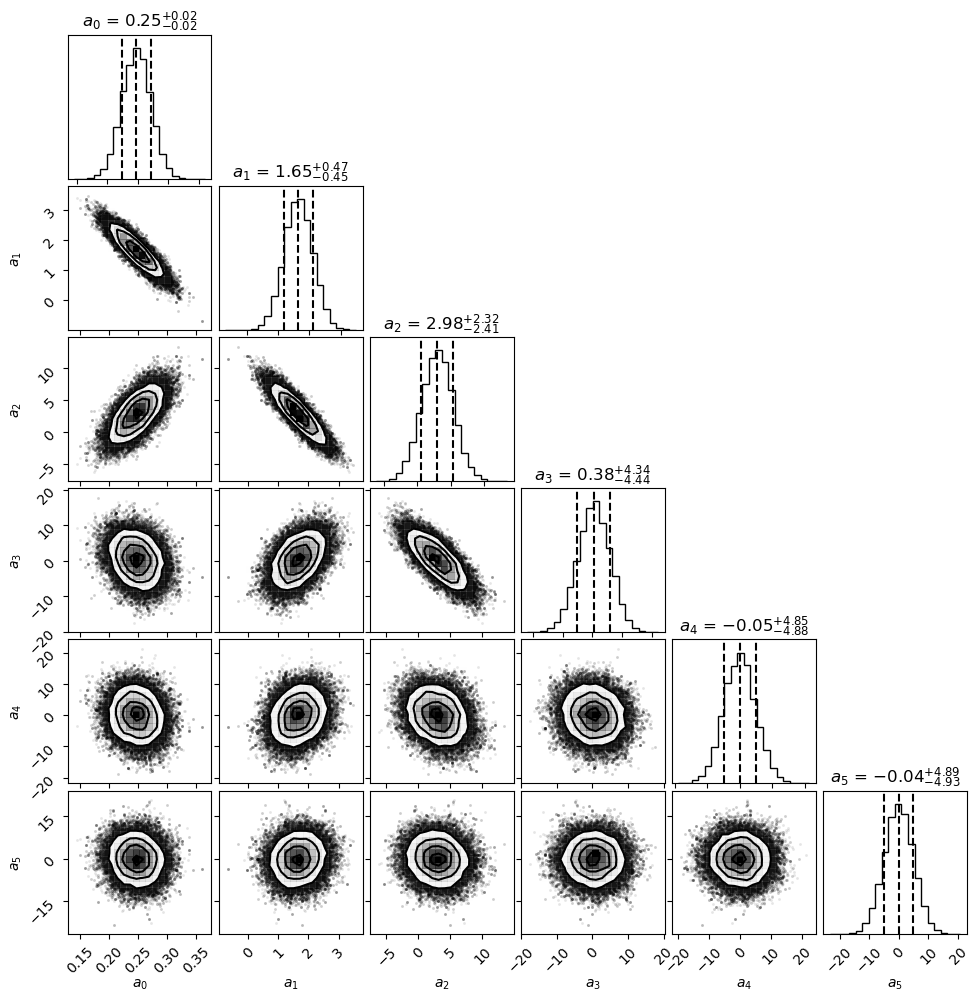

In [109]:
print('emcee sampling (version: )', emcee.__version__)

orders_to_try = 6


ndim = orders_to_try  # number of parameters in the model
nwalkers = 50  # number of MCMC walkers
nsteps = 2000 # steps per walker

print(f'{nwalkers} walkers: {nsteps} samples each')

# initialize walkers
starting_guesses = np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_gaussian_prior, args=[x_data_pts, y_data_pts, dy_data])
%time sampler.run_mcmc(starting_guesses, nsteps)

sampler_flat = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_flat_prior, args=[x_data_pts, y_data_pts, dy_data])
%time sampler_flat.run_mcmc(starting_guesses, nsteps)
print("done")

# We choose a warm-up time
nwarmup = 200 # warm up

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# we'll throw-out the warmup points and reshape:
emcee_trace = sampler.chain[:, nwarmup:, :].reshape(-1, ndim).T
emcee_lnprob = sampler.lnprobability[:, nwarmup:].reshape(-1).T

emcee_trace_flat = sampler_flat.chain[:, nwarmup:, :].reshape(-1, ndim).T
emcee_lnprob_flat = sampler_flat.lnprobability[:, nwarmup:].reshape(-1).T

# Alternatively we can use corner: Gaussian prior
fig, ax = plt.subplots(orders_to_try,orders_to_try, figsize=(10,10))
a_titles = np.char.add(np.char.add(np.full(orders_to_try, "$a_"), np.arange(0, orders_to_try, 1).astype(str)), np.full(orders_to_try, "$"))
corner.corner(emcee_trace.T,labels=a_titles,
                       quantiles=[0.16, 0.5, 0.84],fig=fig,show_titles=True
                       );

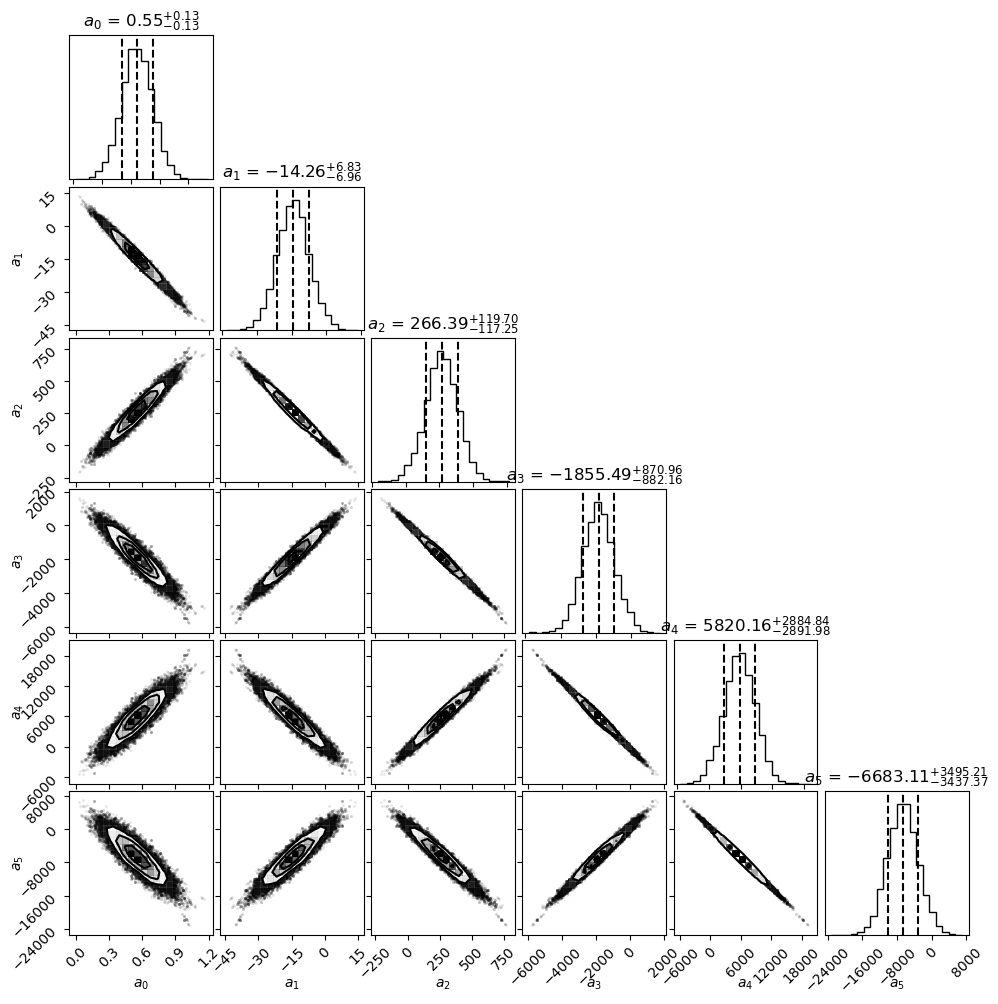

In [110]:
# Alternatively we can use corner: flat prior
fig, ax = plt.subplots(orders_to_try,orders_to_try, figsize=(10,10))
a_titles = np.char.add(np.char.add(np.full(orders_to_try, "$a_"), np.arange(0, orders_to_try, 1).astype(str)), np.full(orders_to_try, "$"))
corner.corner(emcee_trace_flat.T,labels=a_titles,
                       quantiles=[0.16, 0.5, 0.84],fig=fig,show_titles=True
                       );